In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

We will keep adding libraries in libraries as we need them 
Now loading and cleaning the data is upto us 


In [2]:
df = pd.read_csv("churn_dataset.csv")

In [3]:

print(df.sample(10))
print(f"Data types:\n{df.dtypes}\n")

print(f"Information about DataFram: {df.info()}\n")

print(df.shape)


     Account_Age_Months  Total_Purchases  Average_Order_Value  \
427                30.2               22                38.97   
495                13.8               17                58.23   
924                16.3               18                35.98   
613                 7.7               17                45.18   
816                34.4               16                25.09   
139                22.3               13                28.79   
460                17.4               13                38.81   
475                10.0                7                 9.84   
160                 6.7               11                 7.65   
326                16.0               23                37.78   

     Days_Since_Last_Login  Support_Tickets_Opened  \
427                   19.5                       0   
495                   35.5                       0   
924                    2.7                       3   
613                   19.7                       1   
816           

Every column here came in as a number already (float64/int64), no text values hiding inside a numeric column.


In [4]:
print(f"Missing values:\n{df.isnull().sum()}\n")

Missing values:
Account_Age_Months             0
Total_Purchases                0
Average_Order_Value            0
Days_Since_Last_Login          0
Support_Tickets_Opened         0
Is_Subscribed_To_Newsletter    0
Discount_Usage_Ratio           0
Churn                          0
dtype: int64



In [5]:
df.describe(include='all')

,Account_Age_Months,Total_Purchases,Average_Order_Value,Days_Since_Last_Login,Support_Tickets_Opened,Is_Subscribed_To_Newsletter,Discount_Usage_Ratio,Churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,25.693000,15.370000,40.682070,16.945500,1.128000,0.47300,0.384852,0.250000
std,15.617669,5.401692,31.515695,16.898176,1.047241,0.49952,0.175603,0.433229
min,0.400000,3.000000,2.700000,0.000000,0.000000,0.00000,0.027000,0.000000
25%,14.200000,11.000000,20.405000,5.075000,0.000000,0.00000,0.247500,0.000000
50%,22.400000,15.000000,32.255000,11.900000,1.000000,0.00000,0.370500,0.000000
75%,33.650000,19.000000,50.892500,22.625000,2.000000,1.00000,0.510000,0.250000
max,87.000000,42.000000,273.230000,122.700000,5.000000,1.00000,0.896000,1.000000


No weird values in describe, every column has a sensible min and max. lets still check the target and the flag column with value_counts 


In [6]:
df['Churn'].value_counts()

Churn
0    750
1    250
Name: count, dtype: int64

In [7]:
df['Is_Subscribed_To_Newsletter'].value_counts()

Is_Subscribed_To_Newsletter
0    527
1    473
Name: count, dtype: int64

Churn is 750 vs 250 so only 25% of customers actually churn, the classes are imbalanced. 
Newsletter is already 0 and 1 so no mapping is needed on this dataset 


In [8]:
print(df['Support_Tickets_Opened'].value_counts())

print(df['Total_Purchases'].value_counts())

Support_Tickets_Opened
1    368
0    322
2    196
3     92
4     18
5      4
Name: count, dtype: int64
Total_Purchases
13    104
14     78
15     77
11     70
10     67
17     64
16     61
12     56
19     52
18     48
9      42
20     42
21     38
8      33
7      26
22     25
23     21
25     18
24     16
26     12
6       9
27      9
29      7
28      5
4       4
30      4
5       2
33      2
34      2
3       1
32      1
38      1
36      1
42      1
31      1
Name: count, dtype: int64


Nothing needs .map() or astype here, all the columns are already numeric so we can go straight to the model part 


There is no Customer_ID type column in this dataset, every column is a real feature so nothing to drop. we will still run the safe drop so the notebook works even if an ID column shows up later. also dropna just in case. 


In [9]:
try:
    df = df.drop(columns= ['Customer_ID'])
    df = df.dropna()
except KeyError:
    print("Column 'Customer_ID' does not exist in the DataFrame.")
    print("Proceeding without dropping the column.")
print(df.info())
print(df.describe())


Column 'Customer_ID' does not exist in the DataFrame.
Proceeding without dropping the column.
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Account_Age_Months           1000 non-null   float64
 1   Total_Purchases              1000 non-null   int64  
 2   Average_Order_Value          1000 non-null   float64
 3   Days_Since_Last_Login        1000 non-null   float64
 4   Support_Tickets_Opened       1000 non-null   int64  
 5   Is_Subscribed_To_Newsletter  1000 non-null   int64  
 6   Discount_Usage_Ratio         1000 non-null   float64
 7   Churn                        1000 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 62.6 KB
None
       Account_Age_Months  Total_Purchases  Average_Order_Value  \
count         1000.000000      1000.000000          1000.000000   
mean            25.693000        15.370000

In [10]:
# print(f"Missing Records : {df['Days_Since_Last_Login'].isnull().sum()}")
# df['Days_Since_Last_Login']= df['Days_Since_Last_Login'].fillna(df['Days_Since_Last_Login'].median())
# print(f"Missing Records : {df['Days_Since_Last_Login'].isnull().sum()}")


In [11]:
X = df.drop(columns=['Churn'])
X


,Account_Age_Months,Total_Purchases,Average_Order_Value,Days_Since_Last_Login,Support_Tickets_Opened,Is_Subscribed_To_Newsletter,Discount_Usage_Ratio
0,29.8,4,13.14,11.8,0,0,0.474
1,19.7,13,52.99,1.3,0,1,0.389
2,18.4,14,22.18,5.9,2,0,0.615
3,18.4,11,12.82,7.1,3,1,0.773
4,54.2,12,44.27,52.2,1,0,0.606
...,...,...,...,...,...,...,...
995,5.6,8,60.33,6.2,0,0,0.461
996,19.2,19,36.81,17.8,1,1,0.505
997,22.3,21,35.38,2.3,2,1,0.370
998,57.4,12,15.90,19.2,1,1,0.428


In [12]:
y = df['Churn']
y


0      0
1      0
2      0
3      0
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Churn, Length: 1000, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.34,random_state=42)
X_train


,Account_Age_Months,Total_Purchases,Average_Order_Value,Days_Since_Last_Login,Support_Tickets_Opened,Is_Subscribed_To_Newsletter,Discount_Usage_Ratio
477,21.2,27,35.18,15.6,0,0,0.586
404,41.1,13,40.42,5.4,0,0,0.361
172,13.7,20,30.10,12.0,1,1,0.511
125,41.2,13,49.86,34.6,2,1,0.601
394,29.7,24,12.78,1.0,0,1,0.137
...,...,...,...,...,...,...,...
106,21.9,14,16.89,10.5,2,1,0.675
270,12.9,15,24.63,1.1,1,0,0.383
860,62.0,11,26.98,27.4,2,0,0.486
435,14.3,15,17.96,23.9,1,1,0.335


In [14]:
X_test

,Account_Age_Months,Total_Purchases,Average_Order_Value,Days_Since_Last_Login,Support_Tickets_Opened,Is_Subscribed_To_Newsletter,Discount_Usage_Ratio
521,32.6,11,21.01,13.0,1,0,0.187
737,19.2,8,51.12,0.2,3,1,0.577
740,21.5,20,17.48,65.1,0,0,0.446
660,7.4,8,65.21,12.1,0,1,0.400
411,23.4,25,52.81,28.0,0,1,0.191
...,...,...,...,...,...,...,...
316,50.6,27,16.36,1.4,0,1,0.448
706,22.2,21,35.35,9.6,1,1,0.576
547,50.6,9,14.08,38.6,1,0,0.186
872,14.0,10,65.18,10.9,0,1,0.431


As you can see some of our data is extremely big like Average_Order_Value going upto 273 and some are just true and false like Newsletter at 0 and 1s so we have some very overpowering features. 
we have to set them on a scale so nothing becomes overpowered 
we will use a standard scaler for that 


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #Rule of Thumb Always fit_transform on Training and transform on testing data
X_test_scaled = scaler.transform(X_test)


In [16]:
X_train_scaled

array([[-0.2864382 ,  2.09614774, -0.15365108, ..., -1.0843353 ,
        -0.9613523 ,  1.13647159],
       [ 0.98901587, -0.47909559,  0.01632039, ..., -1.0843353 ,
        -0.9613523 , -0.13650415],
       [-0.76713697,  0.80852607, -0.31843258, ..., -0.14514725,
         1.04020139,  0.71214634],
       ...,
       [ 2.32856311, -0.8469875 , -0.41963697, ...,  0.79404081,
        -0.9613523 ,  0.5707046 ],
       [-0.72868107, -0.11120369, -0.71222144, ..., -0.14514725,
         1.04020139, -0.28360356],
       [-0.47230839, -1.58277131,  3.05147884, ...,  0.79404081,
        -0.9613523 ,  0.48018188]], shape=(660, 7))

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0).fit(X_train_scaled,y_train)
print(model.predict(X_train_scaled))
print(f"Training Accuracy: {model.score(X_train_scaled,y_train):.2%}")


[0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1
 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0
 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1
 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0
 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1
 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 

In [18]:
print(model.predict(X_test_scaled))
print(f"Testing Accuracy: {model.score(X_test_scaled,y_test):.2%}")


[0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0]
Testing Accuracy: 84.12%


Keep in mind only 25% of customers actually churn, so a dumb model that always says no churn would still get around 75% accuracy. 
thats why we will also look at the confusion matrix and ROC curve later and not just accuracy 


In [19]:
model1 = LogisticRegression(random_state=0,
C=1,
fit_intercept=True,
).fit(X_train_scaled,y_train)


In [20]:
y_pred = model1.predict(X_test_scaled)
print(y_pred)
print(f"Model Training Data Accuracy: {model1.score(X_train_scaled,y_train):.2%}")


[0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0]
Model Training Data Accuracy: 87.88%


In [21]:
print(f"model1 Testing Accuracy: {model1.score(X_test_scaled,y_test):.2%}")


model1 Testing Accuracy: 84.12%


In [32]:
modeln=LogisticRegression(random_state=9,C=1,fit_intercept=True).fit(X_train,y_train)
yn_pred = modeln.predict(X_test)
print(f"Model Unscaled Training Accuracy: {modeln.score(X_train,y_train):.2%}",f"Model Unscaled Testing Accuracy: {modeln.score(X_test,y_test):.2%}")
print(f"Model Scaled Training Accuracy: {model1.score(X_train_scaled,y_train):.2%}",f"Model Scaled Testing Accuracy: {model1.score(X_test_scaled,y_test):.2%}")


Model Unscaled Training Accuracy: 87.73% Model Unscaled Testing Accuracy: 83.82%
Model Scaled Training Accuracy: 87.88% Model Scaled Testing Accuracy: 84.12%


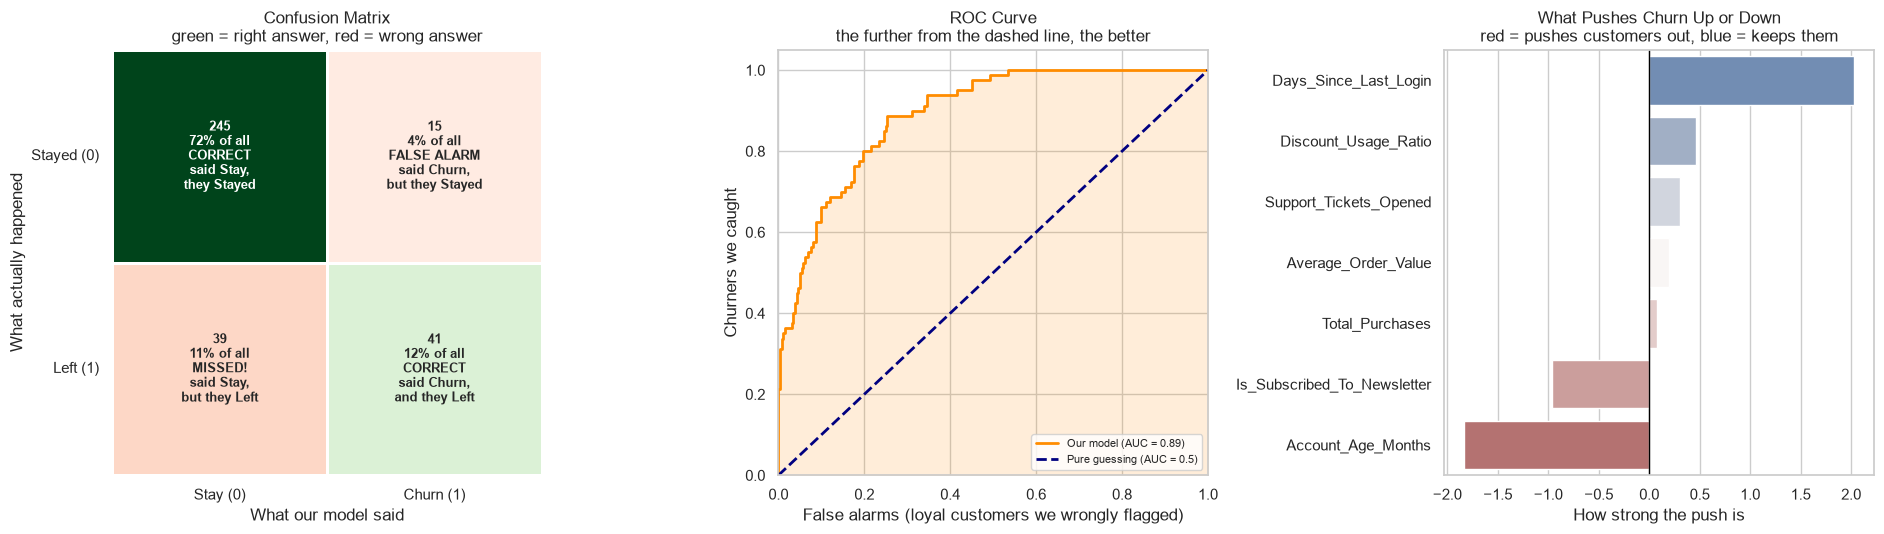

In [40]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set seaborn style for clean visuals
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# ---------------------------------------------------------
# 1. Confusion Matrix  (green = we were right, red = we were wrong)
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
total = cm.sum()

# every square gets plain words: the count, its share, and what it means
meanings = [
    "CORRECT\nsaid Stay,\nthey Stayed",
    "FALSE ALARM\nsaid Churn,\nbut they Stayed",
    "MISSED!\nsaid Stay,\nbut they Left",
    "CORRECT\nsaid Churn,\nand they Left",
]
counts = [f"{v}" for v in cm.flatten()]
shares = [f"{v/total:.0%} of all" for v in cm.flatten()]
cell_labels = np.array([f"{c}\n{s}\n{m}" for c, s, m in zip(counts, shares, meanings)]).reshape(2, 2)

# paint the diagonal (right answers) green and the mistakes red
wrong_mask = np.array([[False, True], [True, False]])   # True = hide this cell
right_mask = ~wrong_mask

sns.heatmap(cm, mask=wrong_mask, annot=cell_labels, fmt='', cmap='Greens',
            vmin=0, vmax=cm.max(), cbar=False, ax=axes[0],
            linewidths=2, linecolor='white', annot_kws={'fontsize': 9, 'fontweight': 'bold'})
sns.heatmap(cm, mask=right_mask, annot=cell_labels, fmt='', cmap='Reds',
            vmin=0, vmax=cm.max(), cbar=False, ax=axes[0],
            linewidths=2, linecolor='white', annot_kws={'fontsize': 9, 'fontweight': 'bold'})

axes[0].set_xticklabels(['Stay (0)', 'Churn (1)'])
axes[0].set_yticklabels(['Stayed (0)', 'Left (1)'], rotation=0)
axes[0].set_xlabel('What our model said')
axes[0].set_ylabel('What actually happened')
axes[0].set_title('Confusion Matrix\ngreen = right answer, red = wrong answer')

# ---------------------------------------------------------
# 2. ROC Curve  (how well the model RANKS customers by churn risk)
# ---------------------------------------------------------
# Requires probability estimates:
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Our model (AUC = {roc_auc:.2f})')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='darkorange')  # the shaded area IS the AUC
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Pure guessing (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False alarms (loyal customers we wrongly flagged)')
axes[1].set_ylabel('Churners we caught')
axes[1].set_title('ROC Curve\nthe further from the dashed line, the better')
axes[1].legend(loc="lower right", fontsize=8)

# ---------------------------------------------------------
# 3. Feature Importance  (what pushes a customer out or keeps them)
# ---------------------------------------------------------
# For Logistic Regression: coefficients
importance = pd.Series(model.coef_[0], index=X_train.columns).sort_values(ascending=False)

# Take top 10 most influential features
top_importance = importance.head(10)
sns.barplot(x=top_importance.values, y=top_importance.index,
            hue=top_importance.index, palette='vlag', legend=False, ax=axes[2])
axes[2].axvline(0, color='black', lw=1)
axes[2].set_title('What Pushes Churn Up or Down\nred = pushes customers out, blue = keeps them')
axes[2].set_xlabel('How strong the push is')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


In [24]:
pd.Series(y_test).value_counts()

Churn
0    260
1     80
Name: count, dtype: int64

In [25]:
roc_auc

0.8902403846153846

In [26]:
# Check correlation of all features with Churn
df.corr()['Churn'].sort_values(ascending=False)


Churn                          1.000000
Days_Since_Last_Login          0.481595
Discount_Usage_Ratio           0.128236
Support_Tickets_Opened         0.083840
Average_Order_Value            0.036102
Total_Purchases               -0.002353
Is_Subscribed_To_Newsletter   -0.232434
Account_Age_Months            -0.279372
Name: Churn, dtype: float64

In [27]:
# Example: Drop the strongest churn signals to make classification harder
X_harder = df.drop(columns=['Churn', 'Days_Since_Last_Login', 'Account_Age_Months', 'Is_Subscribed_To_Newsletter'])

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_harder, y, test_size=0.34, random_state=42
)

scaler_h = StandardScaler()
X_train_scaled_h = scaler_h.fit_transform(X_train_h)
X_test_scaled_h = scaler_h.transform(X_test_h)

model_harder = LogisticRegression(random_state=0).fit(X_train_scaled_h, y_train_h)

print(f"Training Accuracy: {model_harder.score(X_train_scaled_h, y_train_h):.2%}")
print(f"Testing Accuracy: {model_harder.score(X_test_scaled_h, y_test_h):.2%}")


Training Accuracy: 74.09%
Testing Accuracy: 75.88%


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"5-Fold CV Accuracy: {scores.mean():.2%} (+/- {scores.std():.2%})")


5-Fold CV Accuracy: 86.82% (+/- 1.83%)


In [ ]:
# Step 1: Identify Leakage Candidates
# Print features with absolute correlation > 0.8 with the target if not in 0.8 go lower
correlations = df.corr()['Churn'].abs().sort_values(ascending=False)
print("Top Target Correlations:")
print(correlations[correlations > 0.4])


Top Target Correlations:
Churn                    1.000000
Days_Since_Last_Login    0.481595
Name: Churn, dtype: float64


In [39]:
# Step 2: Test Single-Feature Predictability
# If a single feature achieves near 100% accuracy, it is a target leak
from sklearn.metrics import accuracy_score

for col in X.columns:
    acc = accuracy_score(y, X[col] > X[col].median())
    if acc > 0.85:
        print(f"Feature '{col}' alone yields {acc:.2%} accuracy (Potential Leak)")


In [31]:
# Step 3: Train Model Without Suspect Features
# Drop suspected leak columns and re-evaluate
leak_cols = ['Churn'] # Add identified leak columns here
X_clean = df.drop(columns=leak_cols)

X_tr, X_te, y_tr, y_te = train_test_split(X_clean, y, test_size=0.34, random_state=42)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

clean_model = LogisticRegression().fit(X_tr_scaled, y_tr)
print(f"Clean Test Accuracy: {clean_model.score(X_te_scaled, y_te):.2%}")


Clean Test Accuracy: 84.12%
